In [1]:
import glob
import os

import numpy as np
import sklearn.model_selection
import h5py
import torch
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

from whale_gunshot_localization.datasets.dataloaders import get_dataloaders_range_classify_RI
from whale_gunshot_localization.utils.transformations import get_image_transform_range_classify
from whale_gunshot_localization import config

### Helper Functions

In [6]:
def train_test_split_inds(*args, val_size=None, **kwargs):
    """
    Wrapper for sklearn.model_selection.train_test_split which also 
    does a validation split and assumes we are operating on indices
    """

    assert (val_size is None and 'test_size' in kwargs) or (val_size is not None and 'test_size' in kwargs),\
    "If you want to split into two sets, set only 'train_size' and/or 'test_size'."
    
    # if val_size is None, use base function
    if val_size is None:
        train_inds, test_inds = sklearn.model_selection.train_test_split(*args, **kwargs)
        return train_inds, np.asarray([]), test_inds 
        
    # get new test size
    test_size_1 = kwargs['test_size'] + val_size
    test_size_2 = np.around(kwargs['test_size'] / (val_size + kwargs['test_size']), 2)
    
    # first split
    kwargs['test_size'] = test_size_1
    train_inds, remain_inds = sklearn.model_selection.train_test_split(*args, **kwargs)
    
    # second split
    kwargs['test_size'] = test_size_2
    kwargs['train_size'] = None # clear whatever train setting we had for the first split
    val_inds, test_inds = sklearn.model_selection.train_test_split(remain_inds, **kwargs)
    
    return train_inds, val_inds, test_inds

def plot_spects(data, c, r, n):
    """
    Plot random spectrograms and their labels
    """
    
    assert np.floor(n) == n, "n must be a square number"
    
    # get random samples
    idx = np.random.choice(np.arange(data.shape[0]), size=n ** 2, replace=False)
    data = data[idx,...]
    c = c[idx, 0]
    r = r[idx, 0]
    
    # plot
    for i, s in enumerate(data):
        plt.subplot(n, n, i+1)
        plt.imshow(s, aspect='auto')
        if c[i].item():
            plt.title(f"c: {int(c[i].item())}, r: {np.around(r[i].item() * config['scaling']['max_r'], 1)} m",fontsize=8, y=0.95)
        else:
            plt.title(f"c: {int(c[i].item())}", fontsize=8, y=0.95)
        plt.axis('off')

### Create Virtual Dataset

Make main virtual dataset

In [3]:
# get .h5 files in data directory
files = glob.glob(config['dataset']['data_directory'] + '/*.h5')

# remove noise files
noise_files = ['ccb_noise_6s.h5', 'ccb_noise_2023.h5', 'ccb_noise_fs1200.h5', 'sbcex2022.h5']
for nf in noise_files:
    files.remove(os.path.join(config['dataset']['data_directory'], nf))

# we assume we have these entries
assert(all(x in config['dataset']['entry_keys'] for x in ['data', 'T', 'fs']))

# create virtual sources for each entry key
sources_dict = {k : [] for k in config['dataset']['entry_keys']}
sh_dict = {}
dtype_dict = {}
total_length = 0
for i, filename in enumerate(files, start=1):
    with h5py.File(filename, 'r') as f:
        for k in config['dataset']['entry_keys']:
            
            # save entry data shapes
            if i == 1:
                sh_dict[k] = f[k].shape[1:]
                dtype_dict[k] = f[k].dtype
            
            # only add one source for 'T' and 'fs' because they're assumed
            # to all be the same
            if (k == 'T' or k == 'fs') and i > 1:
                continue
            else:
                vsource = h5py.VirtualSource(f[k])
                sources_dict[k].append(vsource)
        
        # add to total length
        total_length += f['data'].shape[0]

# make layouts
layout_dict = {}
for k in config['dataset']['entry_keys']:
    if k != 'T' and k!= 'T':
        layout_dict[k] = h5py.VirtualLayout(shape=(total_length,)+sh_dict[k], dtype=dtype_dict[k])
    else:
        layout_dict[k] = h5py.VirtualLayout(shape=(1,)+sh_dict[k], dtype=dtype_dict[k])

# fill layouts
for k in config['dataset']['entry_keys']:
    offset = 0
    for vsource in sources_dict[k]:
        length = vsource.shape[0]
        layout_dict[k][offset:offset+length] = vsource
        offset += length
        
# create virtual datasets
with h5py.File(config['dataset']['data_directory'] + "/VDS_main.h5", 'w', libver='latest') as f:
    for k in config['dataset']['entry_keys']:
        f.create_virtual_dataset(k, layout_dict[k], fillvalue=0)

Create train/val/test split of the indices

In [4]:
# define split
splits = {'train' : 0.8, 'val' : 0.1, 'test' : 0.1}

# split
inds = train_test_split_inds(np.arange(total_length), train_size = splits['train'], test_size=splits['test'], val_size=splits['val'])

with h5py.File(config['dataset']['data_directory'] + "/" + config['dataset']['noise_data'], 'r') as f:
    num_noises = f['data'].shape[0]
inds_n = train_test_split_inds(np.arange(num_noises), train_size = splits['train'], test_size=splits['test'], val_size=splits['val'])

# save indices
for i, key in enumerate(splits.keys()):
    if np.any(inds[i]):
        np.save(config['dataset']['data_directory'] + f'/{key}_indices.npy', inds[i], allow_pickle=True)
        np.save(config['dataset']['data_directory'] + f'/{key}_noise_indices.npy', inds_n[i], allow_pickle=True)
        print(f'{key} size: (data) {len(inds[i])} -- (noise) {len(inds_n[i])}')

train size: (data) 1207176 -- (noise) 8002
val size: (data) 150897 -- (noise) 1000
test size: (data) 150897 -- (noise) 1001


### Get Data Statistics

In [6]:
dl_train = get_dataloaders_range_classify_RI(splits=['train'], batch_size=128, shuffle=False, transform=None, num_workers=20)['train']

In [7]:
# partial sum, and partial squared sum
psum = torch.zeros((1, dl_train.dataset.size[0]), dtype=torch.float32)
psum_sq = torch.zeros((1, dl_train.dataset.size[0]), dtype=torch.float32)

for inputs, c, r in tqdm(dl_train):
    psum += inputs.sum(axis=(0, 2))
    psum_sq += (inputs ** 2).sum(axis=(0, 2))
    
# calculate mean for each frequency band
count = dl_train.batch_sampler.num_samples * dl_train.dataset.size[1]
total_mean = psum / count

# # calculate var and std
# # var = E[X^2] - E[X]^2
# # std = sqrt(var)
total_var = (psum_sq / count) - (total_mean ** 2)
total_std = torch.sqrt(total_var)

# save results
np.save(config['dataset']['data_directory'] + '/mean_range_classification.npy', total_mean, allow_pickle=True)
np.save(config['dataset']['data_directory'] + '/std_range_classification.npy', total_std, allow_pickle=True)

  0%|          | 0/9432 [00:00<?, ?it/s]

### Show Examples

Text(0.5, 0.98, 'Noise')

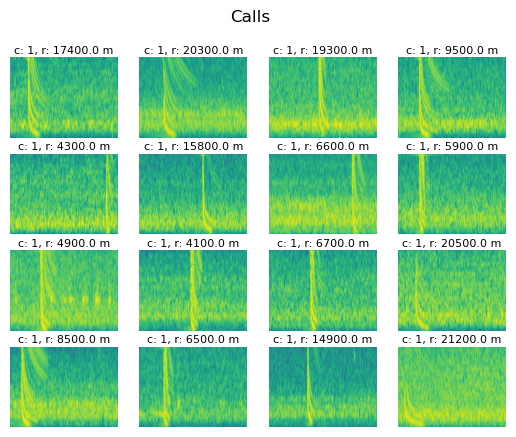

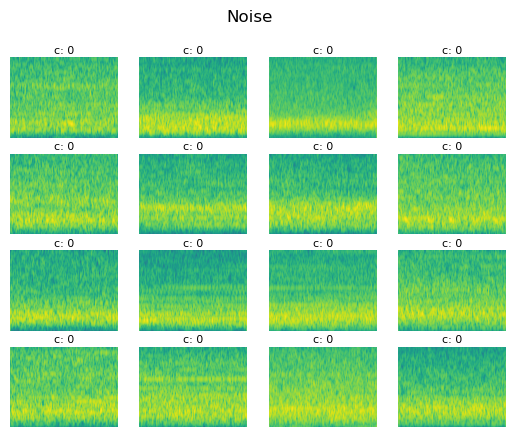

In [7]:
# get batch of data
dl_train = get_dataloaders_range_classify_RI(splits=['train'], batch_size=128, shuffle=True, transform=None, num_workers=20)['train']
inputs, c, r = next(iter(dl_train))

# plot random samples
plt.figure()
plot_spects(inputs[c.squeeze() == 1], c[c.squeeze() == 1], r[c.squeeze() == 1], 4)
plt.suptitle("Calls")

plt.figure()
plot_spects(inputs[c.squeeze() == 0], c[c.squeeze() == 0], r[c.squeeze() == 0], 4)
plt.suptitle("Noise")

### Visualize Label Distributions

Text(0.5, 0, 'SNR [dB]')

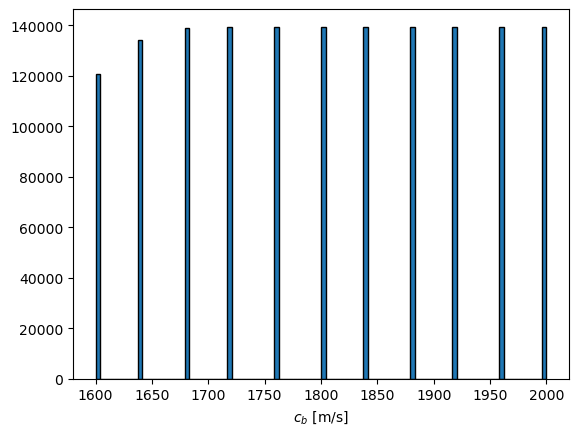

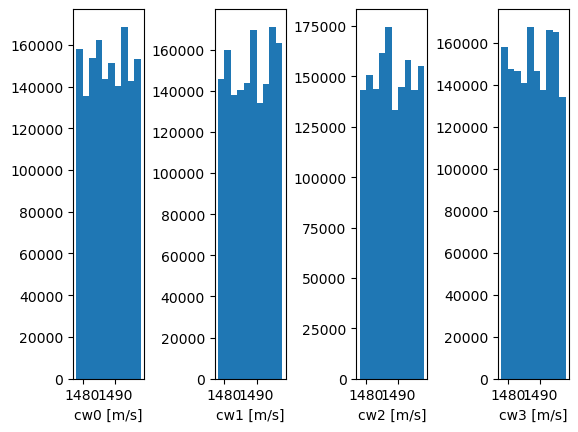

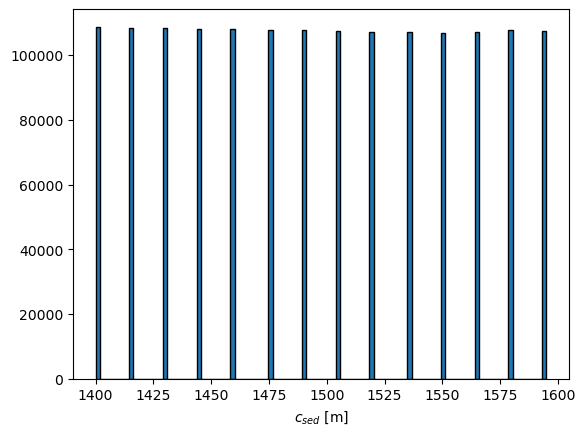

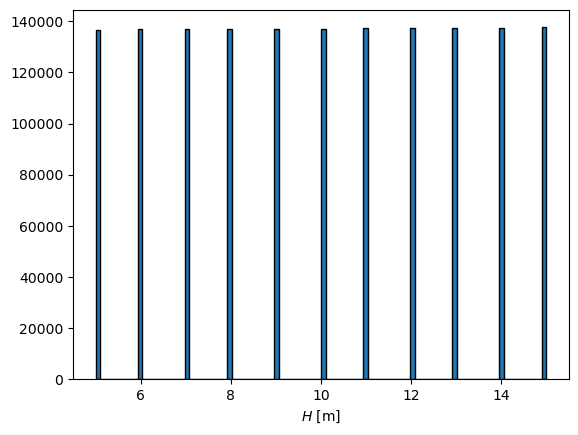

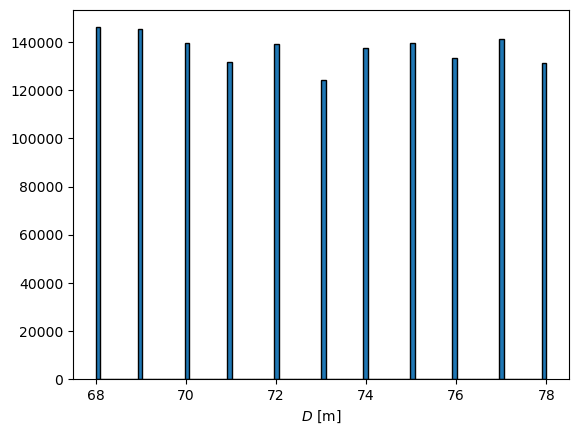

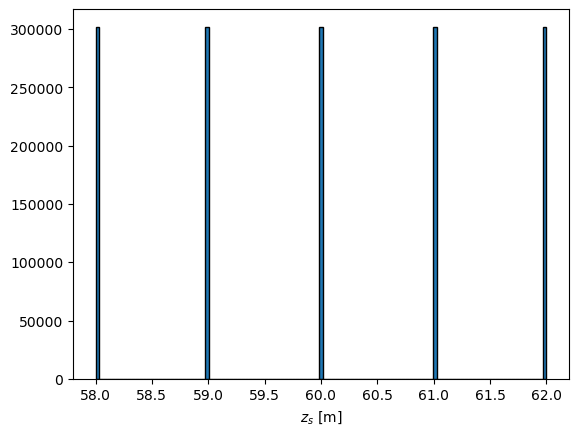

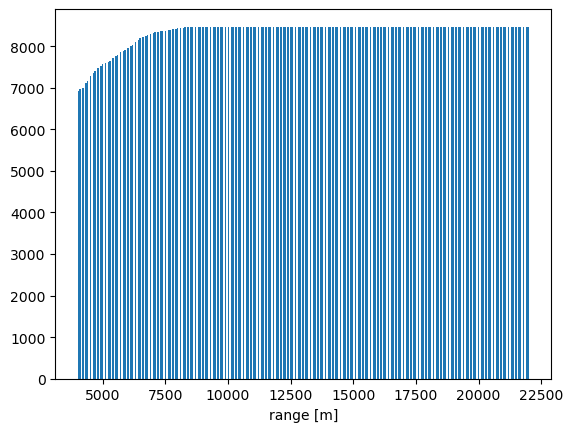

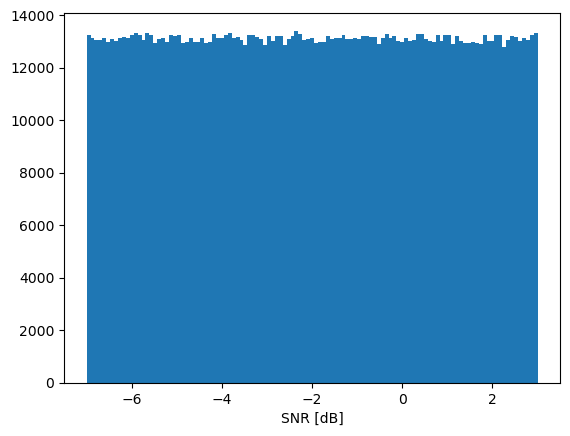

In [2]:
with h5py.File(config['dataset']['data_directory'] + "/VDS_main.h5", 'r') as f:
    cb = f['labels'][:,0]
    cw = f['labels'][:,1:5]
    z_labels = f['labels'][:,5:7]
    c_sed = f['labels'][:,7]
    H = f['labels'][:,8]
    D = f['labels'][:,9]
    r = f['labels'][:,10]
    zs = f['labels'][:,11]
    snr = f['labels'][:,12]
    t_min = f['t_dec_min'][:]
    t_max = f['t_dec_max'][:]

plt.figure()
plt.hist(cb, bins='auto', edgecolor='black')
plt.xlabel("$c_{b}$ [m/s]")

fig, axs = plt.subplots(1,4)
for i in range(cw.shape[1]):
    axs[i].hist(cw[:,i])
    axs[i].set_xlabel(f"cw{i} [m/s]")
fig.subplots_adjust(wspace=1)

plt.figure()
plt.hist(c_sed, bins='auto', edgecolor='black')
plt.xlabel("$c_{sed}$ [m]")

plt.figure()
plt.hist(H, bins='auto', edgecolor='black')
plt.xlabel("$H$ [m]")

plt.figure()
plt.hist(D, bins='auto', edgecolor='black')
plt.xlabel("$D$ [m]")

plt.figure()
plt.hist(zs, bins='auto', edgecolor='black')
plt.xlabel("$z_{s}$ [m]")

plt.figure()
plt.hist(r, bins=301)
plt.xlabel("range [m]")

plt.figure()
plt.hist(snr, bins='auto')
plt.xlabel("SNR [dB]")

### Visualize SSPs

Text(0.5, 1.0, 'Synthetic Sound Speed Profiles')

<Figure size 640x480 with 0 Axes>

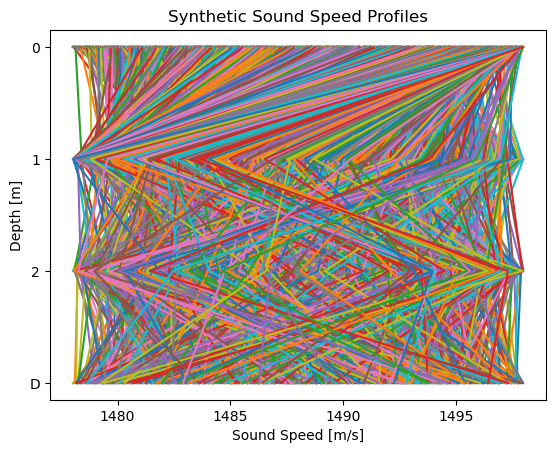

In [13]:
unique_SSPs = np.fliplr(np.unique(cw, axis=0))

fig = plt.figure()
ax = plt.figure().gca()
ax.xaxis.get_major_locator().set_params(integer=True)
ax.set_yticks([0, 1, 2, 3])
ax.set_yticklabels(["D", 2, 1, 0])
for i in range(unique_SSPs.shape[0]):
    ax.plot(unique_SSPs[i,:], [0, 1, 2, 3])
ax.set_xlabel("Sound Speed [m/s]")
ax.set_ylabel("Depth [m]")
ax.set_title("Synthetic Sound Speed Profiles")